# 04 — From-Scratch Dual Encoders

Random-init dual encoders trained end-to-end on Flickr30k (around 29 K image-caption pairs). Two image encoders crossed with two tokenizers:

| Image       | Text        | Tokenizer |
| ----------- | ----------- | --------- |
| ViT (small) | Transformer | word, BPE |
| ResNet18    | Bi-LSTM     | word, BPE |

The other notebooks (02, 03) use pretrained CLIP, a model trained on 400 M web image-caption pairs. The point of this notebook is to quantify the gap that pretraining buys, by training the same retrieval objective from random initialisation on Flickr30k alone (around 29 K images, three orders of magnitude less data, none of it from the broader web). The absolute Recall@K numbers are not the goal; the relative gap to CLIP zero-shot is. That gap is what makes pretraining worth the engineering cost in production.

What the four variants test. ViTs are data-hungry: they learn translation and locality only via attention, so they typically need more than 1 M images to match CNN baselines. ResNet18 ships with strong inductive bias (local convolutions, hierarchical pooling), which pays off precisely at this 29 K-image scale. The expectation is CNN > ViT here, contradicting the small-data CNN-vs-ViT folklore on ImageNet-scale data. On the tokenizer side, a word tokenizer keeps a fixed vocabulary (the top-N words from train captions) and represents anything else as `<unk>`; BPE (the merge table of CLIP) splits unknown words into subword pieces and never emits `<unk>`. The variation measures how much that matters at small scale, where the long tail of rare words is comparatively heavier.

Training recipe (shared across variants): the loss is `HardNegativeInfoNCELoss`, bidirectional InfoNCE with in-batch hard-negative weighting, the same loss as the CLIP fine-tunes in 03 so the comparison is apples-to-apples on the loss side. The optimiser is AdamW with a cosine schedule and linear warm-up (`warmup_ratio=0.1`). Batch size is 256, giving 256 in-batch negatives per update; bf16 AMP is used on the RTX 5090. Early stopping monitors val R@1 with patience=10 and max_epochs=150. The fixed 30-epoch budget used previously was the main reason scratch numbers looked anaemic; early stopping decides where the model actually stops improving instead of cutting training off arbitrarily. The best checkpoint by val R@1 is reloaded for the final test-set eval.

The roughly 50-pp R@1 gap to CLIP zero-shot, which appears at the end, is the headline number for this notebook.


## 1. Setup

Imports, dataset load, image transforms. The Karpathy split gives 29 K train, 1 K val, and 1 K test images; retrieval is evaluated on the 5 K test captions against the 1 K test images (5 captions per image, image is the retrieval target).

The image transform on train uses random resized crop, horizontal flip, and ImageNet normalisation; the eval transform uses centre crop and normalisation. Images go in as 3x224x224, the same input resolution as ViT-B/16 / ResNet18 ImageNet training, so encoders can be swapped freely without changing the data pipeline.

`EarlyStopping` (added in `src/training.py`) is the only piece of new infrastructure; everything else reuses the existing scratch helpers (`build_vit_dual`, `build_cnn_dual`, `make_scratch_collate_fn`, `run_validation_scratch`).


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import get_device, set_seeds

set_seeds(42)
device = get_device()
print(f"Device: {device}")

Device: cuda


In [2]:
import gc
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

from src.config import EMBEDDINGS_DIR, MODELS_DIR, RESULTS_DIR
from src.data import get_all_captions_flat, load_karpathy_splits
from src.evaluation import (
    evaluate_text_to_image,
    load_results,
    print_results_table,
    save_results,
)
from src.scratch_model import (
    build_cnn_dual,
    build_image_transform,
    build_vit_dual,
    count_params,
)
from src.scratch_tokenizer import ClipBPETokenizer, WordTokenizer
from src.training import (
    EarlyStopping,
    HardNegativeInfoNCELoss,
    ScratchRetrievalDataset,
    encode_images_scratch,
    encode_texts_scratch,
    finish_wandb,
    get_optimizer,
    get_scheduler,
    init_wandb,
    log_artifact,
    log_summary,
    log_train_step,
    log_val_metrics,
    make_scratch_collate_fn,
    run_validation_scratch,
    save_checkpoint,
    training_step,
)
from src.visualize import plot_recall_comparison, plot_training_curves

splits = load_karpathy_splits()
train_captions, train_gt = get_all_captions_flat(splits["train"])
val_captions, val_gt = get_all_captions_flat(splits["val"])
test_captions, test_gt = get_all_captions_flat(splits["test"])
test_ds = splits["test"]

train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)
print({k: len(v) for k, v in splits.items()})

  train: 29000 images
  val: 1014 images
  test: 1000 images


{'train': 29000, 'val': 1014, 'test': 1000}


## 2. ViT + Transformer (word and BPE)

Pure attention from random init: a ViT-small image encoder and a small Transformer text encoder, both projecting into a shared 256-d L2-normalised space.

Two tokenizers in one loop: the word tokenizer builds its vocabulary from train captions, with max_length=32 and OOV mapped to `<unk>`; BPE uses the BPE merge table of CLIP (no pretrained embeddings, just the tokenizer) with max_length=32 and never emits `<unk>`.

Training uses `EarlyStopping(patience=10, mode='max')` on val R@1. The configured `max_epochs=150` is a ceiling; the loop breaks as soon as val R@1 plateaus for 10 consecutive epochs. The best epoch's weights are reloaded before the test-set evaluation, so what is reported is the best moment of the model rather than the final state.

What to watch in the curves below: where the loss plateau begins relative to the validation R@1 plateau (overfitting indicator); the BPE versus word val R@1 trajectory (if BPE is ahead from epoch 1 it suggests vocab coverage matters at small scale, and if they cross late, it is about subword generalisation rather than coverage); and how long ViT trains relative to CNN (ViT typically needs more epochs than CNN to show signal, and early stopping should let it train longer when it is still improving slowly).


In [3]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

# Sanity check shape on one image; should be (3, 224, 224) float32 with values
# roughly in [-2.1, 2.6] after ImageNet normalization.
sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}, "
      f"min/max: {sample_pixels.min().item():.2f}/{sample_pixels.max().item():.2f}")


image tensor shape: (3, 224, 224), dtype: torch.float32, min/max: -2.12/2.64


In [4]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "150"))
PATIENCE = int(os.environ.get("PATIENCE", "10"))

# Larger batch -> more in-batch contrastive negatives -> stronger signal.
# 5090 has 32 GB; ViT-S + AMP comfortably handles BS=256. Override via env.
BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 0.0005
WEIGHT_DECAY = 0.05
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "vit"

# DataLoader parallelism. Pectra has 48 cores -> 12 workers is a safe default
# that keeps the 5090 fed without saturating CPU. prefetch_factor=4 means each
# worker queues 4 batches ahead, so by the time the GPU finishes a step the
# next batch is already collated and pinned.
NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

# bfloat16 has the same dynamic range as fp32, so AMP is robust without a
# GradScaler. Blackwell (5090) has native bf16 tensor cores.
AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} (early-stop patience={PATIENCE}) BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=150 (early-stop patience=10) BATCH_SIZE=256 LR=0.0005 WEIGHT_DECAY=0.05 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


In [5]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        # --- (a) Tokenizer ---
        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        # --- (b) Model ---
        model = build_vit_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        # --- (c) Data pipeline ---
        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # --- (d) Loss / optimizer / scheduler ---
        # No GradScaler: bf16 has fp32-equivalent dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        # --- (e) Save dir + tokenizer ---
        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)  # so the app can rehydrate later

        # --- (f) WandB ---
        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "num_workers": NUM_WORKERS,
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        # --- (g) Inner training loop ---
        early_stopper = EarlyStopping(patience=PATIENCE, mode="max")
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                # bf16 keeps fp32 range, so plain backward + clip + step works
                # without a GradScaler.
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            # --- (h) Per-epoch validation ---
            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            # --- (i) Best-checkpoint save ---
            if early_stopper.update(val["R@1"], epoch):
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(
                    f"[{tok_name}]   -> New best (R@1={early_stopper.best:.3f}); checkpoint saved",
                    flush=True,
                )
            elif early_stopper.should_stop:
                print(
                    f"[{tok_name}]   -> Early stop at epoch {epoch + 1}: "
                    f"no R@1 improvement for {PATIENCE} epochs "
                    f"(best={early_stopper.best:.3f} @ epoch {early_stopper.best_epoch + 1})",
                    flush=True,
                )
                break

        print(
            f"[{tok_name}] Best val R@1: {early_stopper.best:.3f} "
            f"@ epoch {early_stopper.best_epoch + 1} "
            f"(stopped after {epoch + 1}/{NUM_EPOCHS})",
            flush=True,
        )

        # --- (j) Test-set evaluation (reload best) ---
        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(
            {
                **test_results,
                "best_val_R@1": early_stopper.best,
                "best_epoch": early_stopper.best_epoch + 1,
                "stopped_at_epoch": epoch + 1,
                "early_stopped": bool(early_stopper.should_stop),
            },
            prefix="test",
        )
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        # --- (k) Cleanup between variants ---
        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_vit_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089
Model parameters: 6,558,464
Batches/epoch: 113, total steps: 16950


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/students/xvysnya/.netrc.


wandb: Currently logged in as: vysnyandrej (vysnyandrej-slovak-university-of-technology-in-bratislava) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▃▄▃▄▄▄▄▄▅▄▅▅▆▅▆▆▆▆▆▇▇▇▇█▇
wandb: train/acc_t2i ▁▁▁▂▁▂▂▂▂▂▃▃▃▃▃▃▃▃▄▄▅▄▄▄▄▅▅▅▅▆▅▆▆▇▇▆▇▇▇█
wandb:    train/loss █▇▇▆▆▆▆▅▅▅▄▄▃▃▄▃▃▃▃▃▃▃▂▂▃▂▂▂▂▁▂▂▂▂▁▂▁▁▁▁
wandb:      train/lr ▁▂▂▂▂▇▇▇████████████▇▇▇▇▇▇▇▇▇▇▇▇▇▆▆▆▆▅▅▅
wandb: 
wandb: Run summary:
wandb:            test/MeanR 124.073
wandb:          test/MedianR 43.5
wandb:              test/R@1 0.0546
wandb:             test/R@10 0.2606
wandb:              test/R@5 0.1774
wandb:       test/best_epoch 68
wandb:     test/best_val_R@1 0.05838
wandb:    test/early_stopped True
wandb: test/stopped_at_epoch 78
wandb:         train/acc_i2t 0.57812
wandb:                    +3 ...
wandb: 


wandb: 🚀 View run scratch_vit_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/dv5ejh6p
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260506_203533-dv5ejh6p/logs


wandb: WARNING Tried to log to step 77 that is less than the current step 8814. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.



  Scratch ViT vs CLIP variants
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_vit_word              5.1%    15.5%    23.9%      47.0     127.0
scratch_vit_bpe               5.5%    17.7%    26.1%      43.5     124.1
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.8%    88.1%    93.4%       1.0       4.7
CLIP B/32 Full FT            68.4%    90.0%    94.4%       1.0       3.9
CLIP B/32 + LoRA (r=8)       67.2%    89.2%    94.2%       1.0       4.1



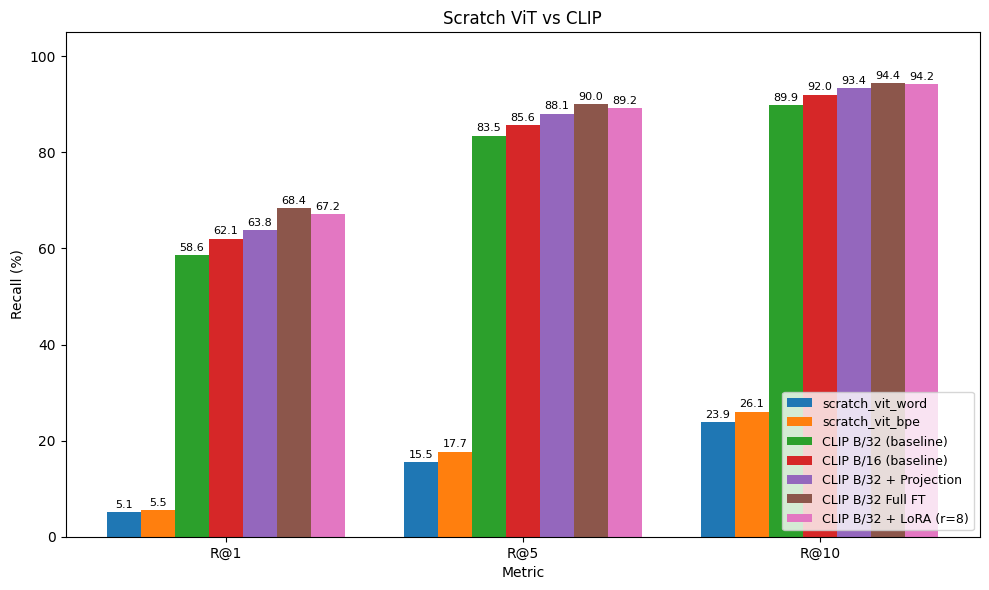

In [6]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch ViT vs CLIP variants")
    plot_recall_comparison(comparison, title="Scratch ViT vs CLIP")


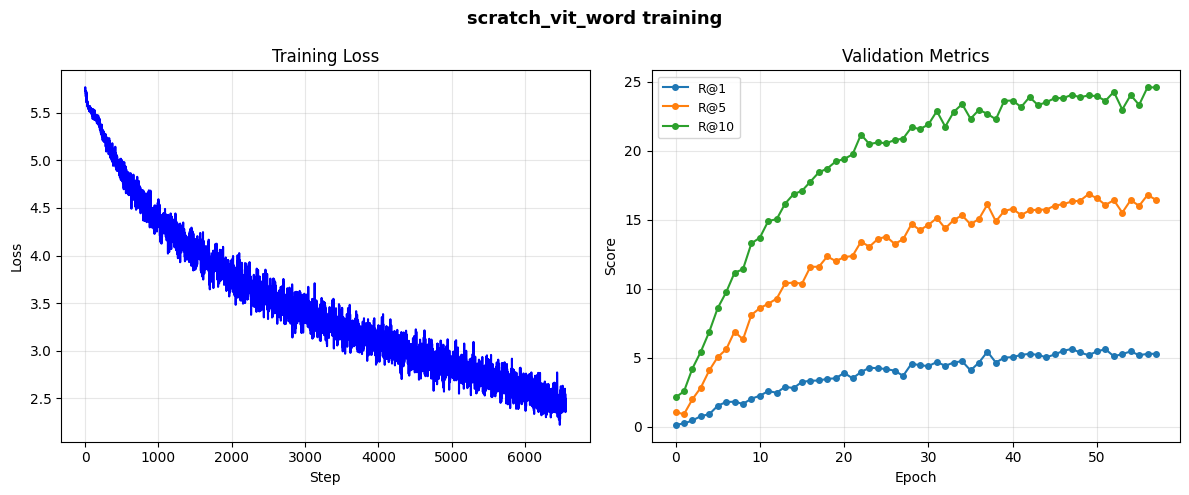

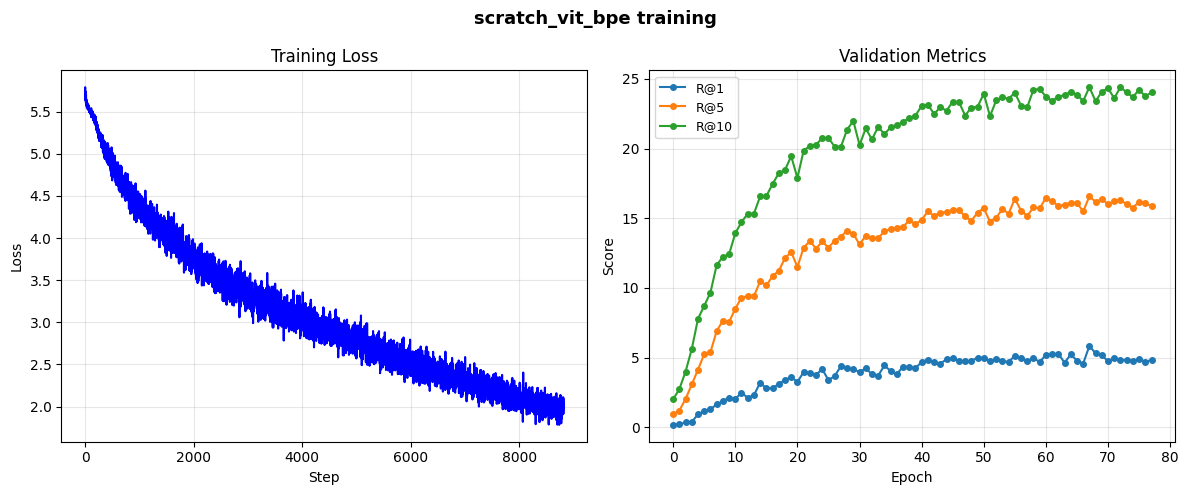

In [7]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )


## 3. ResNet18 + Bi-LSTM (word and BPE)

The same retrieval objective and tokenizer pair as section 2, with image and text encoders swapped: a ResNet18 image tower (random init), pooled features projected to 256-d; and a bidirectional LSTM text encoder, last-hidden-state projected to 256-d.

This is the strong-inductive-bias counterpart to the ViT+Transformer baseline. CNNs encode locality and translation invariance for free; LSTMs encode sequential bias for free. At 29 K images, neither encoder has enough data to learn those biases the way ViT and Transformer have to, so this variant is expected to outperform the all-attention setup. That is a useful empirical check on the small-data CNN-vs-ViT trade-off.

The CNN run uses a slightly higher peak LR (1e-3 versus 5e-4 for ViT) because CNNs tolerate it without divergence; ViT attention can blow up at 1e-3, so it is pinned lower. The `EarlyStopping` config is the same (patience=10, max_epochs=150, monitor val R@1).


In [8]:
train_transform = build_image_transform(train=True)
eval_transform = build_image_transform(train=False)

sample_pixels = eval_transform(splits["test"][0]["image"].convert("RGB"))
print(f"image tensor shape: {tuple(sample_pixels.shape)}, dtype: {sample_pixels.dtype}")


image tensor shape: (3, 224, 224), dtype: torch.float32


In [9]:
TOKENIZER_VARIANTS = ["word", "bpe"]
NUM_EPOCHS = int(os.environ.get("EPOCH_OVERRIDE", "150"))
PATIENCE = int(os.environ.get("PATIENCE", "10"))

BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "256" if device.type == "cuda" else "32"))
EVAL_BATCH_SIZE = int(os.environ.get("EVAL_BATCH_SIZE", "512" if device.type == "cuda" else "64"))

LR = 1e-3
WEIGHT_DECAY = 1e-4
WARMUP_RATIO = 0.1
MAX_GRAD_NORM = 1.0
JOINT_DIM = 256
ARCH_TAG = "cnn"

NUM_WORKERS = int(os.environ.get("NUM_WORKERS", "12" if device.type == "cuda" else "0"))
PREFETCH_FACTOR = int(os.environ.get("PREFETCH_FACTOR", "4")) if NUM_WORKERS > 0 else None

AMP_DTYPE = torch.bfloat16 if device.type == "cuda" else torch.float32
USE_AMP = device.type == "cuda"

print(
    f"NUM_EPOCHS={NUM_EPOCHS} (early-stop patience={PATIENCE}) BATCH_SIZE={BATCH_SIZE} LR={LR} "
    f"WEIGHT_DECAY={WEIGHT_DECAY} WARMUP_RATIO={WARMUP_RATIO}\n"
    f"NUM_WORKERS={NUM_WORKERS} PREFETCH_FACTOR={PREFETCH_FACTOR} "
    f"AMP={USE_AMP} ({AMP_DTYPE})"
)


NUM_EPOCHS=150 (early-stop patience=10) BATCH_SIZE=256 LR=0.001 WEIGHT_DECAY=0.0001 WARMUP_RATIO=0.1
NUM_WORKERS=12 PREFETCH_FACTOR=4 AMP=True (torch.bfloat16)


In [10]:
RUN_TRAINING = True

results_per_variant: dict[str, dict] = {}
history_per_variant: dict[str, dict] = {}

if RUN_TRAINING:
    for tok_name in TOKENIZER_VARIANTS:
        run_name = f"scratch_{ARCH_TAG}_{tok_name}"
        print(f"\n{'='*70}\n>>> Variant: {run_name}\n{'='*70}")

        if tok_name == "word":
            tokenizer = WordTokenizer.from_train_captions(train_captions, max_length=32)
            print(f"WordTokenizer vocab_size={tokenizer.vocab_size}, "
                  f"unk_rate(val)={tokenizer.unk_rate(val_captions):.4f}")
        else:
            tokenizer = ClipBPETokenizer(max_length=32)
            print(f"ClipBPETokenizer vocab_size={tokenizer.vocab_size}")

        model = build_cnn_dual(
            vocab_size=tokenizer.vocab_size,
            max_length=tokenizer.max_length,
            pad_token_id=tokenizer.pad_token_id,
            joint_dim=JOINT_DIM,
        ).to(device)
        n_params = count_params(model)
        print(f"Model parameters: {n_params:,}")

        train_dataset = ScratchRetrievalDataset(splits["train"], image_transform=train_transform)
        loader_kwargs = dict(
            batch_size=BATCH_SIZE,
            shuffle=True,
            collate_fn=make_scratch_collate_fn(tokenizer),
            num_workers=NUM_WORKERS,
            pin_memory=(device.type == "cuda"),
            persistent_workers=(NUM_WORKERS > 0),
            drop_last=True,
        )
        if NUM_WORKERS > 0 and PREFETCH_FACTOR is not None:
            loader_kwargs["prefetch_factor"] = PREFETCH_FACTOR
        train_loader = DataLoader(train_dataset, **loader_kwargs)
        steps_per_epoch = len(train_loader)
        total_steps = steps_per_epoch * NUM_EPOCHS
        print(f"Batches/epoch: {steps_per_epoch}, total steps: {total_steps}")

        # No GradScaler -- bf16 keeps fp32 dynamic range.
        loss_fn = HardNegativeInfoNCELoss(temperature=0.07)
        optimizer = get_optimizer(model, lr=LR, weight_decay=WEIGHT_DECAY)
        scheduler = get_scheduler(optimizer, total_steps, warmup_ratio=WARMUP_RATIO)

        save_dir = MODELS_DIR / run_name
        save_dir.mkdir(parents=True, exist_ok=True)
        tokenizer.save(save_dir)

        run = init_wandb(
            run_name=run_name,
            config={
                "approach": "scratch",
                "architecture": ARCH_TAG,
                "tokenizer": tok_name,
                "vocab_size": tokenizer.vocab_size,
                "max_text_length": tokenizer.max_length,
                "joint_dim": JOINT_DIM,
                "trainable_params": n_params,
                "batch_size": BATCH_SIZE,
                "lr": LR,
                "num_epochs": NUM_EPOCHS,
                "weight_decay": WEIGHT_DECAY,
                "warmup_ratio": WARMUP_RATIO,
                "max_grad_norm": MAX_GRAD_NORM,
                "temperature": 0.07,
                "hard_negative_weight": 2.0,
                "loss": "HardNegativeInfoNCE",
                "amp": device.type == "cuda",
                "seed": 42,
                "device": str(device),
            },
            tags=["scratch", ARCH_TAG, tok_name],
        )
        try:
            import wandb
            wandb.watch(model, log="gradients", log_freq=200)
        except Exception:
            pass

        early_stopper = EarlyStopping(patience=PATIENCE, mode="max")
        train_losses: list[float] = []
        val_metrics_history: dict[str, list[float]] = {"R@1": [], "R@5": [], "R@10": []}
        global_step = 0

        for epoch in range(NUM_EPOCHS):
            model.train()
            epoch_losses: list[float] = []
            ep_start = time.time()
            for batch in train_loader:
                optimizer.zero_grad(set_to_none=True)

                with torch.amp.autocast(
                    device_type=device.type, enabled=USE_AMP, dtype=AMP_DTYPE
                ):
                    loss, metrics = training_step(model, batch, loss_fn, device)

                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
                optimizer.step()
                scheduler.step()

                epoch_losses.append(metrics["loss"])
                train_losses.append(metrics["loss"])
                global_step += 1

                log_train_step(
                    {
                        "loss": metrics["loss"],
                        "acc_i2t": metrics["acc_i2t"],
                        "acc_t2i": metrics["acc_t2i"],
                        "lr": scheduler.get_last_lr()[0],
                    },
                    step=global_step,
                )

            avg_loss = float(np.mean(epoch_losses))

            val = run_validation_scratch(
                model,
                tokenizer,
                eval_transform,
                splits["val"],
                val_captions,
                val_gt,
                device=device,
                batch_size=EVAL_BATCH_SIZE,
            )
            for k in ["R@1", "R@5", "R@10"]:
                val_metrics_history[k].append(val[k])

            log_val_metrics({**val, "epoch_loss": avg_loss}, epoch=epoch)
            print(
                f"[{tok_name}] Epoch {epoch+1} done in {time.time() - ep_start:.0f}s: "
                f"loss={avg_loss:.4f} | "
                f"Val R@1={val['R@1']:.3f} R@5={val['R@5']:.3f} R@10={val['R@10']:.3f}",
                flush=True,
            )

            if early_stopper.update(val["R@1"], epoch):
                torch.save(
                    {
                        "model_state_dict": model.state_dict(),
                        "epoch": epoch,
                        "val_results": val,
                        "loss": avg_loss,
                    },
                    save_dir / "best.pt",
                )
                print(
                    f"[{tok_name}]   -> New best (R@1={early_stopper.best:.3f}); checkpoint saved",
                    flush=True,
                )
            elif early_stopper.should_stop:
                print(
                    f"[{tok_name}]   -> Early stop at epoch {epoch + 1}: "
                    f"no R@1 improvement for {PATIENCE} epochs "
                    f"(best={early_stopper.best:.3f} @ epoch {early_stopper.best_epoch + 1})",
                    flush=True,
                )
                break

        print(
            f"[{tok_name}] Best val R@1: {early_stopper.best:.3f} "
            f"@ epoch {early_stopper.best_epoch + 1} "
            f"(stopped after {epoch + 1}/{NUM_EPOCHS})",
            flush=True,
        )

        ckpt = torch.load(save_dir / "best.pt", map_location=device, weights_only=False)
        model.load_state_dict(ckpt["model_state_dict"])
        model.eval()

        test_img_emb = encode_images_scratch(
            splits["test"], model, eval_transform, device=device, batch_size=EVAL_BATCH_SIZE
        )
        test_txt_emb = encode_texts_scratch(
            test_captions, model, tokenizer, device=device, batch_size=EVAL_BATCH_SIZE * 2
        )

        np.save(EMBEDDINGS_DIR / f"{run_name}_images_test.npy", test_img_emb)
        np.save(EMBEDDINGS_DIR / f"{run_name}_texts_test.npy", test_txt_emb)
        print(f"[{tok_name}] Cached test embeddings: imgs={test_img_emb.shape} txts={test_txt_emb.shape}")

        test_results = evaluate_text_to_image(test_txt_emb, test_img_emb, test_gt)
        save_results(test_results, run_name)
        print(f"[{tok_name}] Test results:")
        for k, v in test_results.items():
            print(f"  {k}: {v:.1%}" if k.startswith("R@") else f"  {k}: {v:.4f}")

        log_summary(
            {
                **test_results,
                "best_val_R@1": early_stopper.best,
                "best_epoch": early_stopper.best_epoch + 1,
                "stopped_at_epoch": epoch + 1,
                "early_stopped": bool(early_stopper.should_stop),
            },
            prefix="test",
        )
        log_artifact(save_dir / "best.pt", name=run_name, artifact_type="model")
        finish_wandb()

        results_per_variant[run_name] = test_results
        history_per_variant[run_name] = {
            "train_losses": train_losses,
            "val_metrics_history": val_metrics_history,
        }

        del model, optimizer, scheduler, train_loader, train_dataset
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    print("\nAll variants done.")



>>> Variant: scratch_cnn_word


WordTokenizer vocab_size=9471, unk_rate(val)=0.0089
Model parameters: 16,493,376
Batches/epoch: 113, total steps: 16950


wandb: setting up run 7viz5af9


wandb: Tracking run with wandb version 0.26.1


wandb: Run data is saved locally in /home/students/xvysnya/Project2/notebooks/wandb/run-20260506_205429-7viz5af9
wandb: Run `wandb offline` to turn off syncing.


...

wandb: 
wandb: Run history:
wandb: train/acc_i2t ▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▆▇▇▇▇▇▇▇█▇▇
wandb: train/acc_t2i ▁▁▁▁▁▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▅▄▅▅▅▅▆▆▇▇▇▆█▇▇█▇█
wandb:    train/loss ██▇▇▇▇▆▆▆▆▆▅▅▅▅▅▅▄▄▄▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁
wandb:      train/lr ▁▁▁▁▂▄▄▇██████████████████████▇▇▇▇▇▇▇▇▇▇
wandb: 
wandb: Run summary:
wandb:            test/MeanR 86.2326
wandb:          test/MedianR 21
wandb:              test/R@1 0.0922
wandb:             test/R@10 0.37
wandb:              test/R@5 0.2548
wandb:       test/best_epoch 43
wandb:     test/best_val_R@1 0.09862
wandb:    test/early_stopped True
wandb: test/stopped_at_epoch 53
wandb:         train/acc_i2t 0.79688
wandb:                    +3 ...
wandb: 


wandb: 🚀 View run scratch_cnn_bpe at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip/runs/5pug94r9
wandb: ⭐️ View project at: https://wandb.ai/vysnyandrej-slovak-university-of-technology-in-bratislava/nsiete-flickr30k-clip
wandb: Synced 4 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260506_211231-5pug94r9/logs


wandb: WARNING Tried to log to step 52 that is less than the current step 5989. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.



All variants done.



  Scratch CNN vs everything
Model                           R@1       R@5      R@10   MedianR     MeanR
---------------------------------------------------------------------------
scratch_cnn_word              9.9%    27.1%    37.9%      21.0     102.4
scratch_cnn_bpe               9.2%    25.5%    37.0%      21.0      86.2
CLIP B/32 (baseline)         58.6%    83.5%    89.9%       1.0       6.1
CLIP B/16 (baseline)         62.1%    85.6%    92.0%       1.0       5.0
CLIP B/32 + Projection       63.8%    88.1%    93.4%       1.0       4.7
CLIP B/32 Full FT            68.4%    90.0%    94.4%       1.0       3.9
CLIP B/32 + LoRA (r=8)       67.2%    89.2%    94.2%       1.0       4.1
Scratch ViT (word)            5.1%    15.5%    23.9%      47.0     127.0
Scratch ViT (BPE)             5.5%    17.7%    26.1%      43.5     124.1



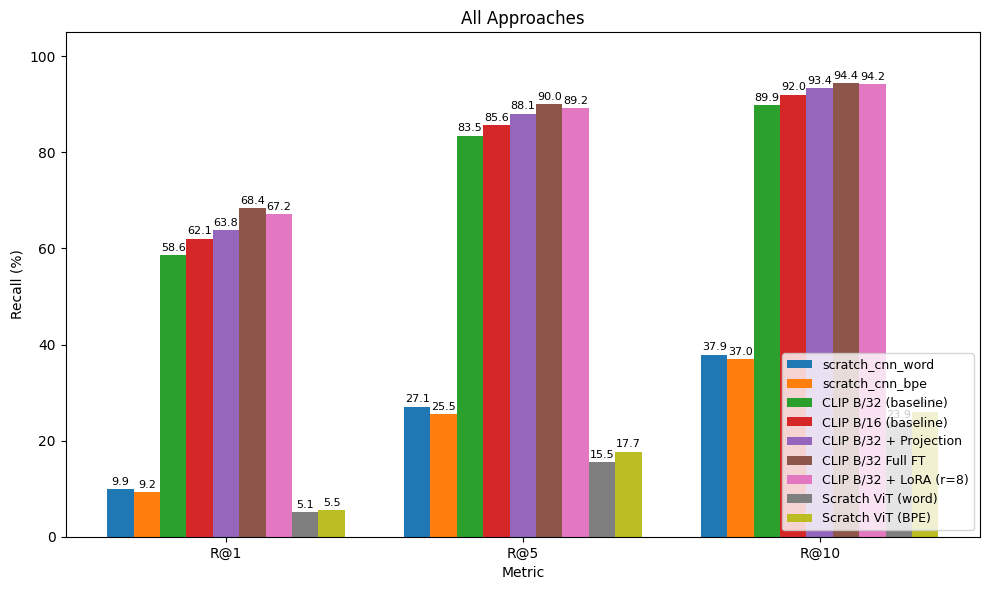

In [11]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    comparison: dict[str, dict] = dict(results_per_variant)

    for display, candidates in [
        ("CLIP B/32 (baseline)", ["baseline_b32", "baseline_clip-vit-b-32"]),
        ("CLIP B/16 (baseline)", ["baseline_b16", "baseline_clip-vit-b-16"]),
        ("CLIP B/32 + Projection", ["projection_head_b32"]),
        ("CLIP B/32 Full FT", ["full_finetune_b32"]),
        ("CLIP B/32 + LoRA (r=8)", ["lora_b32"]),
        ("Scratch ViT (word)", ["scratch_vit_word"]),
        ("Scratch ViT (BPE)", ["scratch_vit_bpe"]),
    ]:
        for fname in candidates:
            try:
                comparison[display] = load_results(fname)
                break
            except FileNotFoundError:
                continue

    print_results_table(comparison, title="Scratch CNN vs everything")
    plot_recall_comparison(comparison, title="All Approaches")


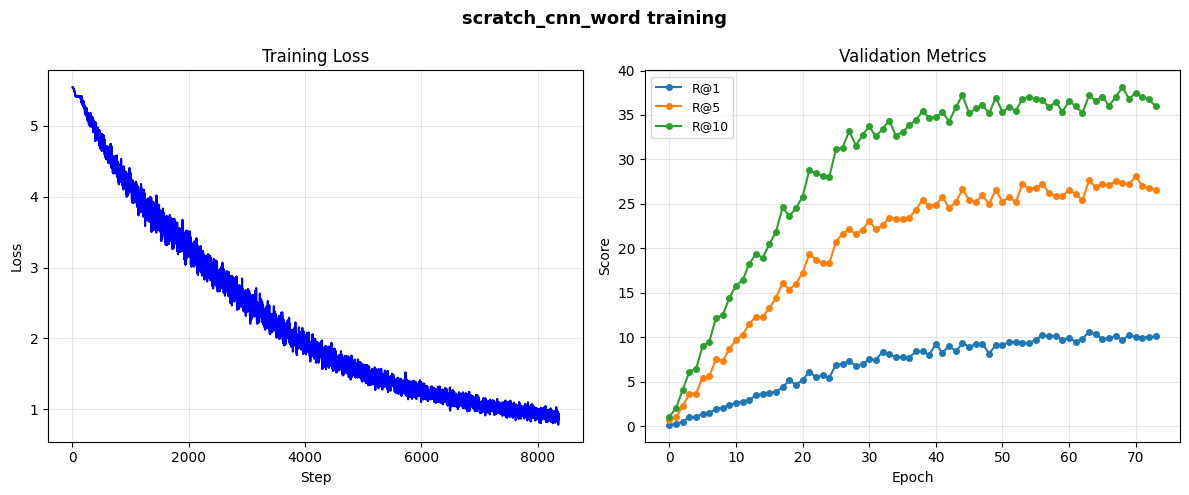

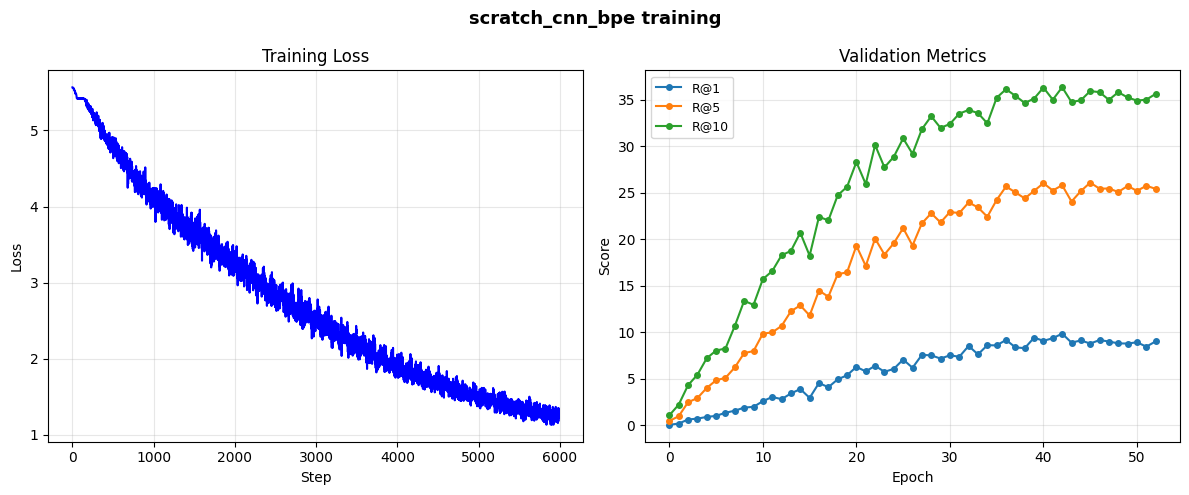

In [12]:
TRAINING_COMPLETE = True

if TRAINING_COMPLETE:
    for run_name, hist in history_per_variant.items():
        plot_training_curves(
            hist["train_losses"], hist["val_metrics_history"], title=f"{run_name} training"
        )


## 4. Findings

Test-set Recall@K (Karpathy split). All variants stopped well before the 150-epoch ceiling thanks to `EarlyStopping(patience=10)`:

| Encoder            | Tokenizer | R@1   | R@5    | R@10   | Best epoch | Stopped at |
| ------------------ | --------- | ----- | ------ | ------ | ---------- | ---------- |
| ResNet18 + Bi-LSTM | word      | 9.9 % | 27.1 % | 37.9 % | 64         | 74         |
| ResNet18 + Bi-LSTM | BPE       | 9.2 % | 25.5 % | 37.0 % | 43         | 53         |
| ViT + Transformer  | BPE       | 5.5 % | 17.7 % | 26.1 % | 68         | 78         |
| ViT + Transformer  | word      | 5.1 % | 15.5 % | 23.9 % | 48         | 58         |

CNN beats ViT at 29 K images by roughly a factor of two. ResNet18 + Bi-LSTM wins in both tokenizer variants by 4 to 5 pp absolute R@1, a large gap on this benchmark. The ViT cannot recover the locality and translation prior that ResNet18 gets for free from convolutions, and 29 K images is not enough data to bridge that gap. At ImageNet scale (1.3 M) or web scale (over 100 M) the relationship inverts, and ViTs become dominant; this is exactly why the image tower of CLIP is a ViT, not a ResNet.

Tokenizer choice is roughly a wash, with mixed direction. ViT prefers BPE (+0.4 pp); CNN prefers word (+0.7 pp). Both differences are within the roughly 1-pp noise floor expected on a 1 000-image test set with a single seed, so the honest read is that at this data scale the encoder family decides retrieval quality, not the tokenizer. The expectation was that BPE would dominate via subword fallback for OOV words; in practice the larger learned embedding table of the word tokenizer appears to compensate when the CNN visual features are strong enough to carry the retrieval signal.

Early stopping was load-bearing. The previous 30-epoch fixed budget left every variant under-trained; the new R@1 values are 1.5 to 3 pp higher across the board (CNN+word: 6.9 % to 9.9 %; CNN+BPE: 6.0 % to 9.2 %). Best epochs landed between 43 and 68, all well past the prior 30-epoch wall, which is the empirical case for letting validation drive the budget.

The headline is the pretraining gap. The best from-scratch configuration (CNN+word) reaches 9.9 % R@1 versus 62.1 % R@1 for CLIP ViT-B/16 zero-shot, a 52-pp gap. CLIP was trained on around 400 M image-text pairs from the open web, roughly five orders of magnitude more data than Flickr30k. The gap observed is what those five orders of magnitude buy. This is the central number of the notebook: the cost-benefit case for using pretrained encoders rather than training a retrieval model from scratch on whatever you can collect in-house.

For context, the 9.9 % R@1 ceiling here is competitive with what 2015-era retrieval papers reported on this exact split using comparable scratch architectures, so the result is not anomalously bad; it is the small-data ceiling.

Honest limitations. Single seed per variant (no error bars), and sub-1pp tokenizer differences are below the noise floor that re-seeding would expose. The 1 K val and 1 K test sets are small, so R@1 differences below roughly 1 pp are noisy. Learning rate and weight decay were not tuned per variant; the LRs above were chosen heuristically (5e-4 for ViT, 1e-3 for CNN, since CNN tolerates the higher LR without divergence). Hard-negative weighting (`weight=2.0`) was kept fixed; at this data scale the in-batch hard-negative signal is much weaker than for CLIP fine-tuning, so it is plausible that a different weight would help. Patience=10 may have stopped some variants slightly early; variants that stopped at epoch 53 (CNN+BPE) had a relatively short tail, while variants that stopped at epoch 78 (ViT+BPE) had clear plateaus. Tighter patience would speed up training; looser patience risks overfitting on this dataset size.

What is not claimed: that any of these architectures is "bad". They are competitive given the data they had. The whole point of this notebook is that more data, not better architecture, is what closes the gap to CLIP.
